In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA  # 新增：导入PCA

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-muted')

In [10]:
# 2. 数据加载与预处理 
# ==========================================
import torch.nn.functional as F

def prepare_bas_dataloaders(num_samples=800, grid_size=4, noise_std=0.1, batch_size=32):
    X = []
    y = []
    # 1. 生成 BAS 数据 (1: Bars/横条纹, -1: Stripes/竖条纹)
    for _ in range(num_samples):
        label = np.random.choice([1, -1])
        img = np.zeros((grid_size, grid_size))
        if label == 1:
            for i in range(grid_size):
                img[i, :] = np.random.choice([0, 1])
        else:
            for j in range(grid_size):
                img[:, j] = np.random.choice([0, 1])
        X.append(img.flatten())
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    # 2. 注入模拟现实情况的加性高斯噪声 (sigma = 0.1)
    X_noisy = X + np.random.normal(0, noise_std, X.shape)

    # ================= 核心修改区域 =================
    # 3. 使用 Average Pooling 替代 PCA 进行空间降采样
    # 将一维数据恢复成 4x4 的图像形状: (num_samples, channels, H, W)
    X_tensor_4x4 = torch.tensor(X_noisy, dtype=torch.float32).view(-1, 1, 4, 4)
    
    # 进行 2x2 平均池化，将 4x4 图像降采样为 2x2 图像 (特征数从 16 降维到 4)
    # 这样完美保留了左上、右上、左下、右下的空间相对位置
    pool = nn.AvgPool2d(kernel_size=2, stride=2)
    X_pooled = pool(X_tensor_4x4) # 输出形状: (-1, 1, 2, 2)
    
    # 展平以便进行数据归一化
    X_pooled_flat = X_pooled.view(X_pooled.size(0), -1).numpy()
    
    # 4. 数据归一化
    # 映射到 [0, pi] 以最大化利用量子角度编码的周期性
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_pooled_flat)

    # 重新转化为 2x2 的空间网格，送入 CNN 和 QCNN 训练
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).view(-1, 1, 2, 2)
    # ===============================================

    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # 训练超参数: batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, len(X_train), len(X_test)

In [11]:
# 3. 量子模型定义 (QCNN)
# ==========================================
# 模拟器设置: 默认使用无噪声状态向量模拟器 (default.qubit)
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def conv_layer(w, wires):
    qml.RY(w[0], wires=wires[0])
    qml.RY(w[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    # 根据 PCA d=4，采用角度编码，将 4 维特征映射到 4 个量子比特
    qml.AngleEmbedding(features=inputs, wires=range(n_qubits))

    # 堆叠卷积层以确保模型容量与经典基线一致 (约 32 ± 5 个可训练参数)
    # 5层 x 3块 x 2参数 = 30个参数
    for i in range(5):
        conv_layer(weights[6*i : 6*i+2], wires=[0, 1])
        conv_layer(weights[6*i+2 : 6*i+4], wires=[2, 3])
        conv_layer(weights[6*i+4 : 6*i+6], wires=[1, 2])

    return qml.expval(qml.PauliZ(0))

class QuantumCNN(nn.Module):
    def __init__(self):
        super(QuantumCNN, self).__init__()
        # 权重总数为 30
        self.qlayer = qml.qnn.TorchLayer(qnode, {"weights": (30,)})

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.qlayer(x)

In [12]:
# 4. 经典模型定义 (Classical CNN) 
# ==========================================
class ClassicalCNN(nn.Module):
    def __init__(self):
        super(ClassicalCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=2)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(6, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)
        return torch.tanh(self.fc(x))

In [13]:
# 5. 统一训练与评估函数
# ==========================================
def train_model(model, train_loader, epochs=100, lr=0.01):
    """所有基于梯度的模型使用 Adam 优化器，学习率 0.01，最大 100 轮训练"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loss_history = []

    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            # 【重要修复】使用 view(-1, 1) 强行对齐，解决因 broadcasting 引发的隐藏MSE计算错误
            loss = criterion(outputs.view(-1, 1), labels.view(-1, 1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    train_time = time.time() - start_time
    return loss_history, train_time

def evaluate_model(model, test_loader):
    model.eval()
    all_y_true = []
    all_y_pred_continuous = []

    start_time = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            all_y_true.extend(labels.numpy().flatten())
            all_y_pred_continuous.extend(outputs.numpy().flatten())

    inference_time = time.time() - start_time

    y_true_bin = np.array(all_y_true)
    y_score = np.array(all_y_pred_continuous)

    # 将连续输出转换为离散标签 (1 或 -1)
    y_pred_bin = np.sign(y_score)
    y_pred_bin[y_pred_bin == 0] = 1

    # 计算指标
    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)

    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': roc_auc,
        'InferTime': inference_time,
        'fpr': fpr,
        'tpr': tpr
    }

In [14]:
# 6. 执行训练与计时
# ==========================================
train_loader, test_loader, n_train, n_test = prepare_bas_dataloaders(num_samples=800, grid_size=4, noise_std=0.1, batch_size=32)
print(f"==> Generating Data... Train Set: {n_train}, Test Set: {n_test}")

epochs_num = 100
learning_rate = 0.01

print(f"\n⏳ [1/2] Training Quantum CNN (QCNN) on {n_train} samples...")
qcnn = QuantumCNN()
q_loss_hist, q_train_time = train_model(qcnn, train_loader, epochs=epochs_num, lr=learning_rate)
print(f"✅ QCNN Training completed in {q_train_time:.4f} seconds.")

print(f"\n⏳ [2/2] Training Classical CNN on {n_train} samples...")
cnn = ClassicalCNN()
c_loss_hist, c_train_time = train_model(cnn, train_loader, epochs=epochs_num, lr=learning_rate)
print(f"✅ CNN Training completed in {c_train_time:.4f} seconds.")

==> Generating Data... Train Set: 640, Test Set: 160

⏳ [1/2] Training Quantum CNN (QCNN) on 640 samples...
✅ QCNN Training completed in 36.4947 seconds.

⏳ [2/2] Training Classical CNN on 640 samples...
✅ CNN Training completed in 2.0953 seconds.


In [15]:
# 7. 模型评估
# ==========================================
print("\n==> Evaluating models...")
metrics_q = evaluate_model(qcnn, test_loader)
metrics_c = evaluate_model(cnn, test_loader)

metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
print("\nFinal Results Summary (BAS Dataset, Noise σ=0.1):")
for m in metric_keys:
    print(f"{m:10s} -> Classical CNN: {metrics_c[m]:.4f} | Quantum CNN: {metrics_q[m]:.4f}")


==> Evaluating models...

Final Results Summary (BAS Dataset, Noise σ=0.1):
Accuracy   -> Classical CNN: 0.8250 | Quantum CNN: 0.8187
Precision  -> Classical CNN: 0.8537 | Quantum CNN: 0.9014
Recall     -> Classical CNN: 0.8140 | Quantum CNN: 0.7442
F1-Score   -> Classical CNN: 0.8333 | Quantum CNN: 0.8153
AUC-ROC    -> Classical CNN: 0.9305 | Quantum CNN: 0.9150



==> Generating visual analysis...


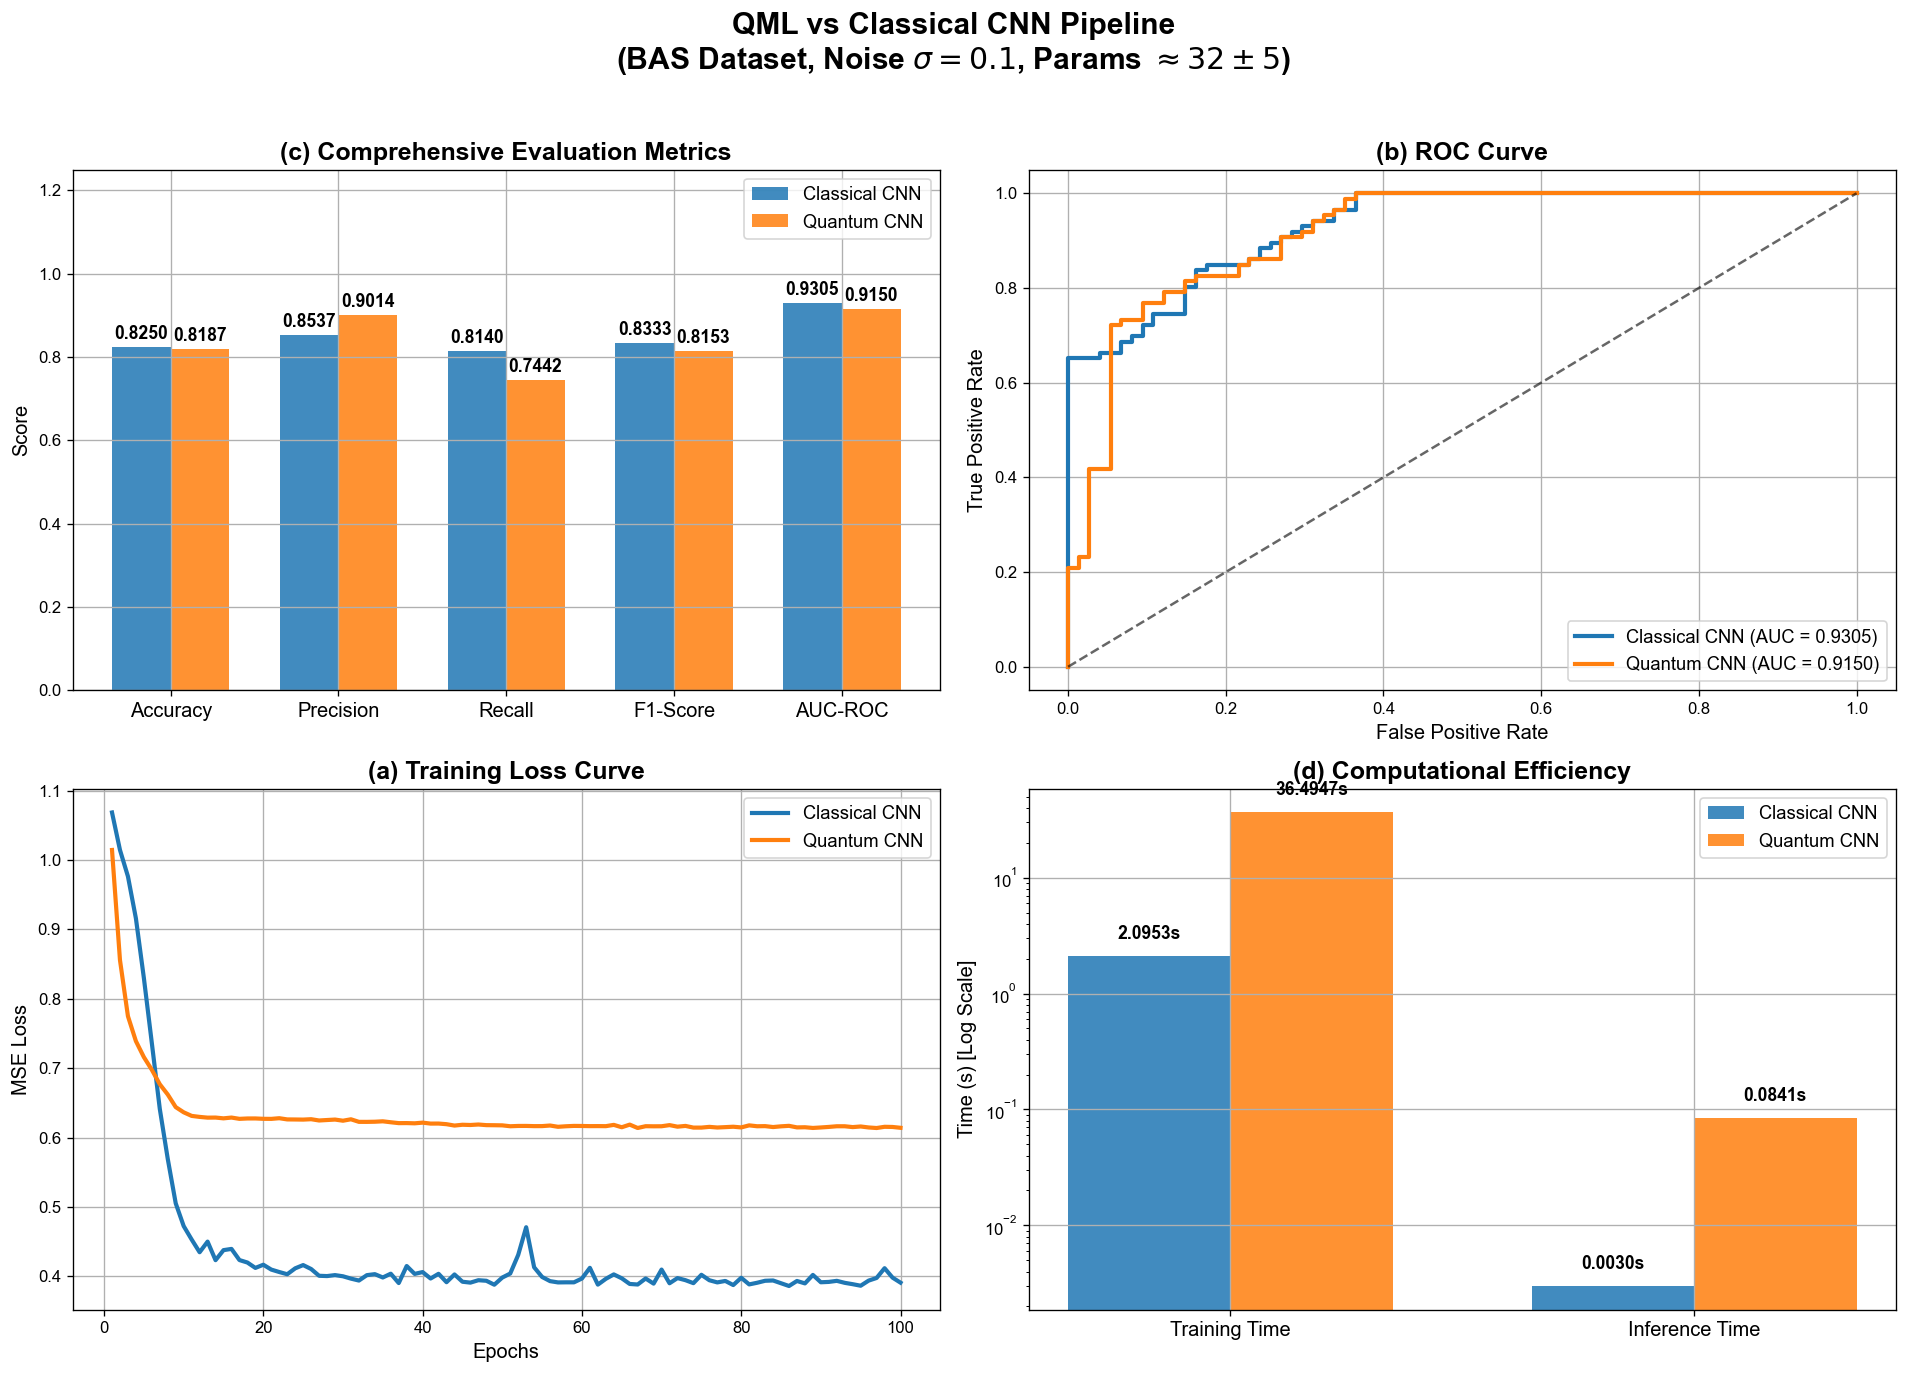

In [16]:
# 8. 结果可视化（已优化：所有柱状图加上精确数字标签）
# ==========================================
print("\n==> Generating visual analysis...")

fig, axs = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
color_c = '#1f77b4'
color_q = '#ff7f0e'

fig.suptitle('QML vs Classical CNN Pipeline\n'
             '(BAS Dataset, Noise $\\sigma=0.1$, Params $\\approx 32 \\pm 5$)',
             fontsize=18, fontweight='bold', y=0.98)

# Helper function for bar labels
def autolabel(rects, ax, fmt='.4f', unit='', y_offset=0.01):
    """为柱状图添加数值标签"""
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + y_offset,
                f'{height:{fmt}}{unit}',
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

# [左上] 综合评估指标
x_metrics = np.arange(len(metric_keys))
width = 0.35
rects1 = axs[0, 0].bar(x_metrics - width/2, [metrics_c[k] for k in metric_keys], 
                       width, label='Classical CNN', color=color_c, alpha=0.85)
rects2 = axs[0, 0].bar(x_metrics + width/2, [metrics_q[k] for k in metric_keys], 
                       width, label='Quantum CNN', color=color_q, alpha=0.85)

autolabel(rects1, axs[0, 0])
autolabel(rects2, axs[0, 0])

axs[0, 0].set_xticks(x_metrics)
axs[0, 0].set_xticklabels(metric_keys, fontsize=12)
axs[0, 0].set_ylim(0, 1.25)
axs[0, 0].set_ylabel('Score', fontsize=12)
axs[0, 0].set_title('(c) Comprehensive Evaluation Metrics', fontsize=15, fontweight='bold')
axs[0, 0].legend(fontsize=11)

# [右上] ROC 曲线
axs[0, 1].plot(metrics_c['fpr'], metrics_c['tpr'], 
               label=f"Classical CNN (AUC = {metrics_c['AUC-ROC']:.4f})", 
               color=color_c, linewidth=2.5)
axs[0, 1].plot(metrics_q['fpr'], metrics_q['tpr'], 
               label=f"Quantum CNN (AUC = {metrics_q['AUC-ROC']:.4f})", 
               color=color_q, linewidth=2.5)
axs[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axs[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axs[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axs[0, 1].set_title('(b) ROC Curve', fontsize=15, fontweight='bold')
axs[0, 1].legend(fontsize=11)

# [左下] 训练损失曲线
axs[1, 0].plot(range(1, epochs_num + 1), c_loss_hist, label='Classical CNN', 
               color=color_c, linewidth=2.5)
axs[1, 0].plot(range(1, epochs_num + 1), q_loss_hist, label='Quantum CNN', 
               color=color_q, linewidth=2.5)
axs[1, 0].set_xlabel('Epochs', fontsize=12)
axs[1, 0].set_ylabel('MSE Loss', fontsize=12)
axs[1, 0].set_title('(a) Training Loss Curve', fontsize=15, fontweight='bold')
axs[1, 0].legend(fontsize=11)

# [右下] 计算效率 (对数坐标)
x_time = np.arange(2)
time_keys = ['Training Time', 'Inference Time']
rects3 = axs[1, 1].bar(x_time - width/2, 
                       [c_train_time, metrics_c['InferTime']], 
                       width, label='Classical CNN', color=color_c, alpha=0.85)
rects4 = axs[1, 1].bar(x_time + width/2, 
                       [q_train_time, metrics_q['InferTime']], 
                       width, label='Quantum CNN', color=color_q, alpha=0.85)

# 时间柱状图专用标签（log scale 使用 annotate 更稳健）
for rect in list(rects3) + list(rects4):
    height = rect.get_height()
    axs[1, 1].annotate(f'{height:.4f}s',
                       xy=(rect.get_x() + rect.get_width()/2., height),
                       xytext=(0, 8), textcoords='offset points',
                       ha='center', va='bottom', fontsize=10.5, fontweight='bold')

axs[1, 1].set_xticks(x_time)
axs[1, 1].set_xticklabels(time_keys, fontsize=12)
axs[1, 1].set_yscale('log')
axs[1, 1].set_ylabel('Time (s) [Log Scale]', fontsize=12)
axs[1, 1].set_title('(d) Computational Efficiency', fontsize=15, fontweight='bold')
axs[1, 1].legend(fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()